# Pack & Ship Store Analytics

> **All data in this notebook is simulated.** It is not real sales data from The UPS Store, UPS, or any other business. See `README.md` for how it was built.

**Business question:** which services and customers make this store the most money, and where should the owner focus to grow profit?

The notebook works through that question in ten steps, using SQL against the store's database and a chart for each step. After each chart there is a **takeaway** cell for you to fill in, and the last section is your recommendation to the owner.

**To run it:** put this notebook in the `pack-ship-store-analytics` folder, next to `pack_ship_store.db`, and choose **Run All**. In Google Colab, run the optional cell below first.

In [1]:
# Google Colab only: remove the # from the four lines below, run this cell,
# and choose pack-ship-store-analytics.zip when asked. Skip this cell anywhere else.
# from google.colab import files
# files.upload()
# !unzip -q pack-ship-store-analytics.zip
# %cd pack-ship-store-analytics

## Setup

In [2]:
import sqlite3
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

DB_PATH = Path("pack_ship_store.db")
if not DB_PATH.exists():
    raise FileNotFoundError("Can't find pack_ship_store.db. Put this notebook in the pack-ship-store-analytics folder.")
con = sqlite3.connect(DB_PATH)


def sql(query):
    """Run a SQL query against the store database and return the result as a DataFrame."""
    return pd.read_sql_query(query, con)


def show(df, money=(), pct=(), count=(), decimals=()):
    """Return a copy of a table formatted for reading: dollars, percentages and counts."""
    out = df.copy()
    formats = [(money, "${:,.0f}"), (pct, "{:.1%}"), (count, "{:,.0f}"), (decimals, "{:,.2f}")]
    for columns, fmt in formats:
        for col in columns:
            out[col] = out[col].map(lambda v, fmt=fmt: "" if pd.isna(v) else fmt.format(v))
    return out


# Chart style: a quiet surface, hairline grid, and two colors checked for colorblind safety.
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#184f95", "#0d366b"]
).with_extremes(bad=SURFACE)
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.size": 10,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlecolor": INK,
    "axes.titlepad": 12, "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "legend.frameon": False, "lines.linewidth": 2,
    "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
})
DOLLARS = mtick.FuncFormatter(lambda x, _: f"${x:,.0f}")
THOUSANDS = mtick.FuncFormatter(lambda x, _: "$0" if x == 0 else f"${x / 1000:,.0f}K")
PERCENT = mtick.PercentFormatter(1.0, decimals=0)

## One definition of a sale

Every query below reads from a `sales` view, so the revenue rule is applied the same way everywhere:

- **Voided transactions are left out.** They were rung up and then cancelled.
- **Refunds are kept.** They're recorded as negative amounts, so they cancel out the original sale.
- **Revenue is `line_revenue`**, which is after discounts and before sales tax.
- **Gross profit is revenue minus `line_cost`.**

In [3]:
con.executescript("""
DROP VIEW IF EXISTS sales;
CREATE TEMP VIEW sales AS
SELECT i.line_id, i.transaction_id, i.service_id, i.quantity, i.unit_price, i.discount_amount,
       i.line_revenue, i.line_cost, i.line_revenue - i.line_cost AS gross_profit,
       t.transaction_datetime, t.status, t.employee_id, t.customer_id, t.customer_type,
       s.service_name, s.category, s.labor_min_per_line, s.labor_min_per_unit
FROM transaction_items AS i
JOIN transactions AS t USING (transaction_id)
JOIN services AS s USING (service_id)
WHERE t.status <> 'Voided';
""")
show(sql("SELECT COUNT(*) AS line_items, SUM(line_revenue) AS revenue, SUM(gross_profit) AS gross_profit FROM sales"),
     money=["revenue", "gross_profit"], count=["line_items"])

,line_items,revenue,gross_profit
0,"77,797","$1,466,129","$760,790"


## 1. Check the data first

Before analyzing anything, confirm what the tables contain and what needs cleaning.

In [4]:
sql("""
SELECT 'transactions' AS table_name, COUNT(*) AS row_count FROM transactions
UNION ALL SELECT 'transaction_items', COUNT(*) FROM transaction_items
UNION ALL SELECT 'shipments', COUNT(*) FROM shipments
UNION ALL SELECT 'customers', COUNT(*) FROM customers
UNION ALL SELECT 'employees', COUNT(*) FROM employees
UNION ALL SELECT 'shifts', COUNT(*) FROM shifts
UNION ALL SELECT 'services', COUNT(*) FROM services
""")

,table_name,row_count
0,transactions,45542
1,transaction_items,78099
2,shipments,29366
3,customers,388
4,employees,7
5,shifts,2101
6,services,34


In [5]:
sql("""
SELECT status,
       COUNT(*) AS transactions,
       SUM(employee_id IS NULL) AS missing_cashier,
       MIN(transaction_datetime) AS first_transaction,
       MAX(transaction_datetime) AS last_transaction
FROM transactions
GROUP BY status
""")

,status,transactions,missing_cashier,first_transaction,last_transaction
0,Completed,45248,226,2024-09-03 08:08:12,2026-08-31 18:58:55
1,Refund,113,0,2024-09-07 13:53:44,2026-08-24 11:06:25
2,Voided,181,1,2024-09-04 18:57:21,2026-08-26 09:08:46


In [6]:
# Do the register totals match the line items? A register total is line revenue plus sales tax.
sql("""
SELECT COUNT(*) AS transactions_checked,
       SUM(ABS(t.total - t.sales_tax - x.line_total) > 0.015) AS mismatches
FROM transactions AS t
JOIN (SELECT transaction_id, SUM(line_revenue) AS line_total
      FROM transaction_items GROUP BY transaction_id) AS x USING (transaction_id)
""")

,transactions_checked,mismatches
0,45542,0


**Your takeaway:** _What did the checks show, and what will your analysis leave out or keep?_

## 2. Which services bring in revenue, and which bring in profit?

Revenue and gross profit are totaled by service category, then each category's share of the store total is compared. Return drop-offs are left out of the chart because they bring in no revenue.

In [7]:
by_category = sql("""
SELECT category,
       SUM(line_revenue) AS revenue,
       SUM(gross_profit) AS gross_profit
FROM sales
GROUP BY category
ORDER BY revenue DESC
""")
by_category["margin"] = by_category["gross_profit"] / by_category["revenue"]
by_category["share_of_revenue"] = by_category["revenue"] / by_category["revenue"].sum()
by_category["share_of_profit"] = by_category["gross_profit"] / by_category["gross_profit"].sum()
show(by_category, money=["revenue", "gross_profit"], pct=["margin", "share_of_revenue", "share_of_profit"])

,category,revenue,gross_profit,margin,share_of_revenue,share_of_profit
0,Shipping,"$799,267","$194,754",24.4%,54.5%,25.6%
1,Printing,"$285,457","$235,452",82.5%,19.5%,30.9%
2,Packing supplies,"$121,997","$95,115",78.0%,8.3%,12.5%
3,Mailbox,"$113,580","$103,676",91.3%,7.7%,13.6%
4,Notary,"$65,865","$65,865",100.0%,4.5%,8.7%
5,Other services,"$51,199","$40,108",78.3%,3.5%,5.3%
6,Packing services,"$20,700","$20,700",100.0%,1.4%,2.7%
7,Retail,"$8,064","$5,121",63.5%,0.5%,0.7%
8,Returns,$0,$0,,0.0%,0.0%


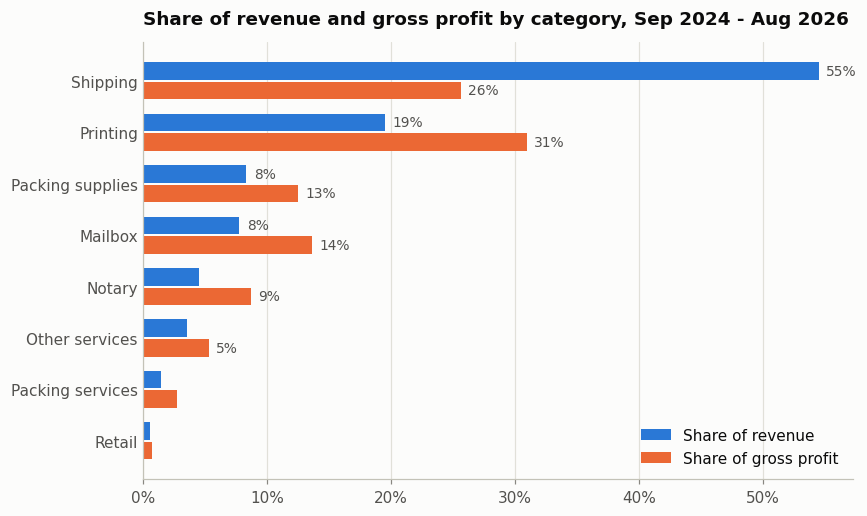

In [8]:
chart = by_category[by_category["revenue"] > 0].iloc[::-1]  # largest category at the top
y = np.arange(len(chart))
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(y + 0.19, chart["share_of_revenue"], height=0.34, color=BLUE, label="Share of revenue")
ax.barh(y - 0.19, chart["share_of_profit"], height=0.34, color=ORANGE, label="Share of gross profit")
for i, (rev, gp) in enumerate(zip(chart["share_of_revenue"], chart["share_of_profit"])):
    for value, offset in ((rev, 0.19), (gp, -0.19)):
        if value >= 0.05:
            ax.text(value + 0.006, i + offset, f"{value:.0%}", va="center", fontsize=9, color=INK_2)
ax.set_yticks(y, chart["category"])
ax.xaxis.set_major_formatter(PERCENT)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_title("Share of revenue and gross profit by category, Sep 2024 - Aug 2026")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Your takeaway:** _Compare each category's share of revenue with its share of profit. Which categories earn more than their share, and which earn less?_

## 3. Is the store growing?

Revenue and gross profit by month, then the latest 12 months compared with the 12 months before.

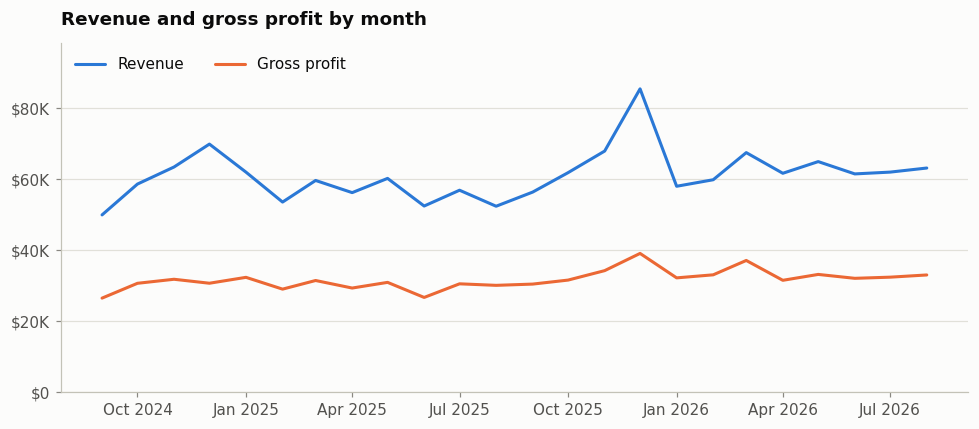

In [9]:
monthly = sql("""
SELECT strftime('%Y-%m', transaction_datetime) AS month,
       SUM(line_revenue) AS revenue,
       SUM(gross_profit) AS gross_profit
FROM sales
GROUP BY month
ORDER BY month
""")
monthly["month"] = pd.to_datetime(monthly["month"], format="%Y-%m")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly["month"], monthly["revenue"], color=BLUE, label="Revenue")
ax.plot(monthly["month"], monthly["gross_profit"], color=ORANGE, label="Gross profit")
ax.set_ylim(0, monthly["revenue"].max() * 1.15)
ax.yaxis.set_major_formatter(THOUSANDS)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.grid(axis="x", visible=False)
ax.set_title("Revenue and gross profit by month")
ax.legend(loc="upper left", ncols=2)
plt.tight_layout()
plt.show()

In [10]:
periods = sql("""
SELECT CASE WHEN transaction_datetime < '2025-09-01' THEN 'Sep 2024 - Aug 2025'
            ELSE 'Sep 2025 - Aug 2026' END AS period,
       SUM(line_revenue) AS revenue,
       SUM(gross_profit) AS gross_profit,
       COUNT(DISTINCT CASE WHEN status = 'Completed' THEN transaction_id END) AS transactions
FROM sales
GROUP BY period
ORDER BY period
""")
display(show(periods, money=["revenue", "gross_profit"], count=["transactions"]))
change = periods.set_index("period").pct_change().iloc[-1]
print(f"Change: revenue {change['revenue']:+.1%}, gross profit {change['gross_profit']:+.1%}, "
      f"transactions {change['transactions']:+.1%}")

,period,revenue,gross_profit,transactions
0,Sep 2024 - Aug 2025,"$695,591","$360,485","21,966"
1,Sep 2025 - Aug 2026,"$770,538","$400,305","23,282"


Change: revenue +10.8%, gross profit +11.0%, transactions +6.0%


**Your takeaway:** _Is the store growing? Which months are busiest? Does the growth come from more transactions or from higher prices?_

## 4. Who are the customers?

Transactions, revenue and margin for each customer type, then the ten biggest business accounts.

,customer_type,transactions,revenue,gross_profit,share_of_transactions,share_of_revenue,margin
0,Walk-in,"37,449","$803,432","$405,735",82.8%,54.8%,50.5%
1,Business account,"3,163","$437,133","$199,516",7.0%,29.8%,45.6%
2,Mailbox holder,"4,636","$225,564","$155,539",10.2%,15.4%,69.0%


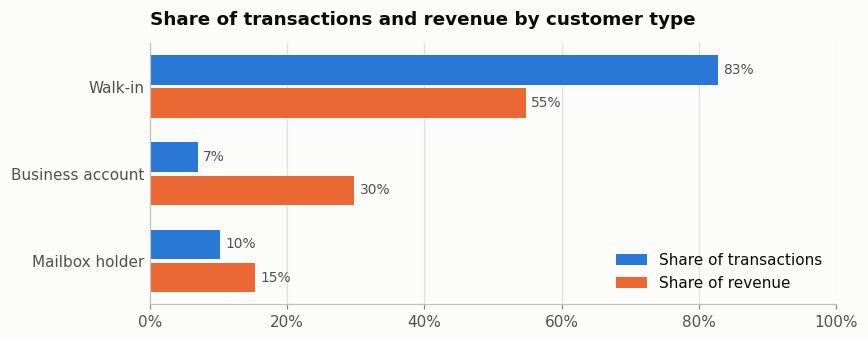

In [11]:
by_customer = sql("""
SELECT customer_type,
       COUNT(DISTINCT CASE WHEN status = 'Completed' THEN transaction_id END) AS transactions,
       SUM(line_revenue) AS revenue,
       SUM(gross_profit) AS gross_profit
FROM sales
GROUP BY customer_type
ORDER BY revenue DESC
""")
by_customer["share_of_transactions"] = by_customer["transactions"] / by_customer["transactions"].sum()
by_customer["share_of_revenue"] = by_customer["revenue"] / by_customer["revenue"].sum()
by_customer["margin"] = by_customer["gross_profit"] / by_customer["revenue"]
display(show(by_customer, money=["revenue", "gross_profit"], count=["transactions"],
             pct=["share_of_transactions", "share_of_revenue", "margin"]))

chart = by_customer.iloc[::-1]
y = np.arange(len(chart))
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(y + 0.19, chart["share_of_transactions"], height=0.34, color=BLUE, label="Share of transactions")
ax.barh(y - 0.19, chart["share_of_revenue"], height=0.34, color=ORANGE, label="Share of revenue")
for i, (tx, rev) in enumerate(zip(chart["share_of_transactions"], chart["share_of_revenue"])):
    ax.text(tx + 0.008, i + 0.19, f"{tx:.0%}", va="center", fontsize=9, color=INK_2)
    ax.text(rev + 0.008, i - 0.19, f"{rev:.0%}", va="center", fontsize=9, color=INK_2)
ax.set_yticks(y, chart["customer_type"])
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PERCENT)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_title("Share of transactions and revenue by customer type")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [12]:
top_accounts = sql("""
SELECT s.customer_id, c.industry, c.status AS account_status, c.close_date,
       COUNT(DISTINCT CASE WHEN s.status = 'Completed' THEN s.transaction_id END) AS visits,
       SUM(s.line_revenue) AS revenue,
       SUM(s.gross_profit) AS gross_profit
FROM sales AS s
JOIN customers AS c USING (customer_id)
WHERE s.customer_type = 'Business account'
GROUP BY s.customer_id
ORDER BY revenue DESC
LIMIT 10
""")
show(top_accounts, money=["revenue", "gross_profit"], count=["visits"])

,customer_id,industry,account_status,close_date,visits,revenue,gross_profit
0,B1005,E-commerce seller,Active,NaN,206,"$34,323","$7,873"
1,B1007,E-commerce seller,Active,NaN,165,"$32,517","$7,238"
2,B1001,E-commerce seller,Closed,2025-05-16,130,"$28,683","$6,567"
3,B1003,E-commerce seller,Active,NaN,185,"$27,869","$6,410"
4,B1008,E-commerce seller,Active,NaN,220,"$26,067","$6,090"
5,B1004,E-commerce seller,Active,NaN,224,"$25,841","$6,615"
6,B1002,E-commerce seller,Active,NaN,131,"$23,506","$5,257"
7,B1006,E-commerce seller,Active,NaN,137,"$22,895","$5,107"
8,B1012,Real estate office,Active,NaN,96,"$17,084","$13,800"
9,B1019,Law office,Active,NaN,149,"$16,160","$8,707"


**Your takeaway:** _Compare each group's share of transactions with its share of revenue. What happens to the store when a big business account leaves? Check the account status column._

## 5. What do return drop-offs bring in?

Customers dropping off prepaid returns pay nothing, but they do come into the store. This counts how many visits are return drop-offs and how often those customers also buy something.

Return drop-offs: 13,939 of 45,248 visits (31%). 11% of them included a purchase.


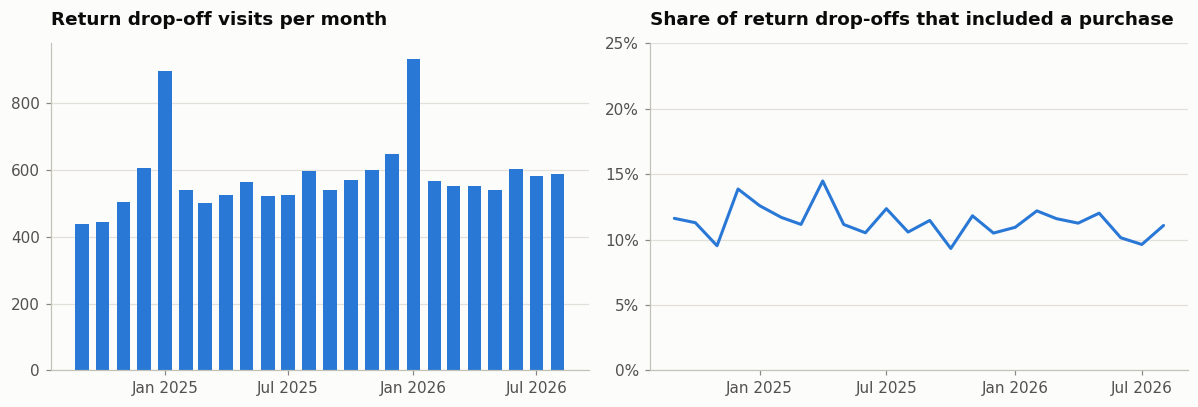

In [13]:
returns = sql("""
WITH visit AS (
    SELECT transaction_id,
           strftime('%Y-%m', MIN(transaction_datetime)) AS month,
           MAX(service_id = 'RET-DROP') AS is_return,
           SUM(line_revenue) AS revenue
    FROM sales
    WHERE status = 'Completed'
    GROUP BY transaction_id
)
SELECT month,
       COUNT(*) AS visits,
       SUM(is_return) AS return_visits,
       SUM(is_return = 1 AND revenue > 0) AS returns_with_a_purchase
FROM visit
GROUP BY month
ORDER BY month
""")
returns["month"] = pd.to_datetime(returns["month"], format="%Y-%m")
total = returns[["visits", "return_visits", "returns_with_a_purchase"]].sum()
print(f"Return drop-offs: {total['return_visits']:,} of {total['visits']:,} visits "
      f"({total['return_visits'] / total['visits']:.0%}). "
      f"{total['returns_with_a_purchase'] / total['return_visits']:.0%} of them included a purchase.")

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8))
left.bar(returns["month"], returns["return_visits"], width=20, color=BLUE)
left.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
left.set_title("Return drop-off visits per month")
right.plot(returns["month"], returns["returns_with_a_purchase"] / returns["return_visits"], color=BLUE)
right.set_ylim(0, 0.25)
right.yaxis.set_major_formatter(PERCENT)
right.set_title("Share of return drop-offs that included a purchase")
for ax in (left, right):
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

**Your takeaway:** _How much of the store's traffic is return drop-offs, and is it growing? What could the store offer these customers while they're at the counter?_

## 6. Do shipping customers buy packing supplies?

The attach rate is the share of shipping visits that also include packing supplies or a packing service, split by who was at the register. Business accounts are left out because most bring their own packaging.

,first_name,role,shipping_visits,with_packing,attach_rate
0,Maria,Store manager,"3,015","1,222",40.5%
1,Kevin,Senior associate,"3,938","2,020",51.3%
2,Aisha,Associate,"3,711","1,469",39.6%
3,Daniel,Associate,"1,310",441,33.7%
4,Priya,Associate,"1,227",485,39.5%
5,Tom,Associate,377,151,40.1%
6,Sam,Seasonal associate,610,156,25.6%


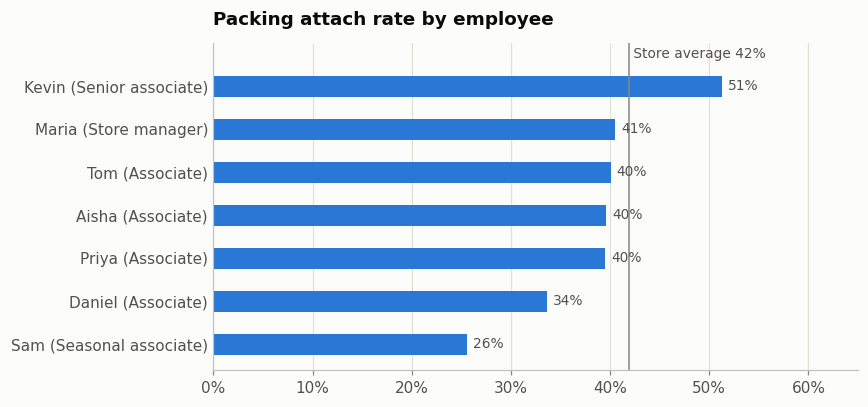

In [14]:
attach = sql("""
WITH visit AS (
    SELECT transaction_id, employee_id,
           MAX(category = 'Shipping') AS has_shipping,
           MAX(category IN ('Packing supplies', 'Packing services')) AS has_packing
    FROM sales
    WHERE status = 'Completed' AND customer_type <> 'Business account' AND employee_id IS NOT NULL
    GROUP BY transaction_id
)
SELECT e.first_name, e.role,
       SUM(v.has_shipping) AS shipping_visits,
       SUM(v.has_shipping AND v.has_packing) AS with_packing
FROM visit AS v
JOIN employees AS e USING (employee_id)
GROUP BY e.employee_id
ORDER BY e.employee_id
""")
attach["attach_rate"] = attach["with_packing"] / attach["shipping_visits"]
store_rate = attach["with_packing"].sum() / attach["shipping_visits"].sum()
display(show(attach, count=["shipping_visits", "with_packing"], pct=["attach_rate"]))

chart = attach.sort_values("attach_rate")
y = np.arange(len(chart))
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(y, chart["attach_rate"], height=0.5, color=BLUE)
ax.axvline(store_rate, color=MUTED, linewidth=1)
ax.text(store_rate, len(chart) - 0.4, f" Store average {store_rate:.0%}", color=INK_2, fontsize=9, va="bottom")
for i, rate in enumerate(chart["attach_rate"]):
    ax.text(rate + 0.006, i, f"{rate:.0%}", va="center", fontsize=9, color=INK_2)
ax.set_yticks(y, chart["first_name"] + " (" + chart["role"] + ")")
ax.set_ylim(-0.6, len(chart))
ax.set_xlim(0, 0.65)
ax.xaxis.set_major_formatter(PERCENT)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_title("Packing attach rate by employee")
plt.tight_layout()
plt.show()

**Your takeaway:** _How much does the attach rate vary between employees? What would it be worth if everyone matched the top rate?_

In [15]:
# Try it: estimate the extra packing sales if every employee matched the top attach rate.
# Hint: for each employee, extra visits = (top rate - their rate) x their shipping visits.
# Then multiply by the average packing sale on the visits that had one.

## 7. Did the June 2025 printing promotion pay off?

The store took 15% off all printing in June 2025. This compares walk-in and mailbox-holder printing from April to August 2025 with the same months in 2026, when there was no promotion.

,year,month,print_visits,revenue,gross_profit,discounts
0,2025,4,328,"$5,388","$4,494",$0
1,2025,5,290,"$5,636","$4,688",$0
2,2025,6,317,"$5,034","$4,068",$888
3,2025,7,256,"$4,578","$3,831",$0
4,2025,8,324,"$5,571","$4,667",$0
5,2026,4,351,"$6,580","$5,510",$0
6,2026,5,320,"$5,989","$4,998",$0
7,2026,6,306,"$6,429","$5,358",$0
8,2026,7,275,"$6,001","$5,001",$0
9,2026,8,383,"$8,063","$6,716",$0


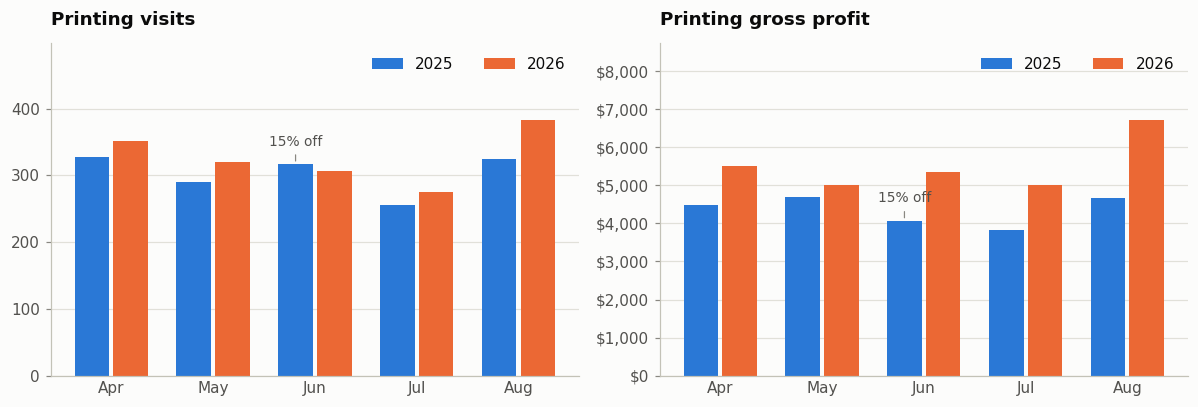

In [16]:
promo = sql("""
SELECT CAST(strftime('%Y', transaction_datetime) AS INTEGER) AS year,
       CAST(strftime('%m', transaction_datetime) AS INTEGER) AS month,
       COUNT(DISTINCT transaction_id) AS print_visits,
       SUM(line_revenue) AS revenue,
       SUM(gross_profit) AS gross_profit,
       SUM(discount_amount) AS discounts
FROM sales
WHERE status = 'Completed'
  AND category = 'Printing'
  AND customer_type <> 'Business account'
  AND CAST(strftime('%m', transaction_datetime) AS INTEGER) BETWEEN 4 AND 8
GROUP BY year, month
ORDER BY year, month
""")
display(show(promo, money=["revenue", "gross_profit", "discounts"], count=["print_visits"]))

months = ["Apr", "May", "Jun", "Jul", "Aug"]
x = np.arange(len(months))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, col, title in ((axes[0], "print_visits", "Printing visits"),
                       (axes[1], "gross_profit", "Printing gross profit")):
    for year, color, offset in ((2025, BLUE, -0.19), (2026, ORANGE, 0.19)):
        values = promo[promo["year"] == year].set_index("month")[col].reindex(range(4, 9))
        ax.bar(x + offset, values, width=0.34, color=color, label=str(year))
    june_2025 = promo.loc[(promo["year"] == 2025) & (promo["month"] == 6), col].iloc[0]
    ax.annotate("15% off", xy=(2 - 0.19, june_2025), xytext=(0, 12), textcoords="offset points",
                ha="center", fontsize=9, color=INK_2,
                arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.8))
    ax.set_ylim(0, promo[col].max() * 1.3)
    ax.set_xticks(x, months)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="x", length=0)
    ax.set_title(title)
    ax.legend(loc="upper right", ncols=2)
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
axes[1].yaxis.set_major_formatter(DOLLARS)
plt.tight_layout()
plt.show()

**Your takeaway:** _Did the discount bring in more printing customers? Did it bring in more profit? Would you run it again?_

## 8. How many mailbox holders renew?

For each box size and rental term, renewals are counted from rental payments during the period, and cancellations from boxes that closed. The renewal rate is renewals divided by renewals plus cancellations.

,mailbox_size,term_months,boxes,renewals,cancellations,renewal_rate
0,Large,12,27,19,6,76.0%
1,Medium,6,52,77,26,74.8%
2,Medium,12,60,64,10,86.5%
3,Small,6,106,163,57,74.1%
4,Small,12,107,114,15,88.4%


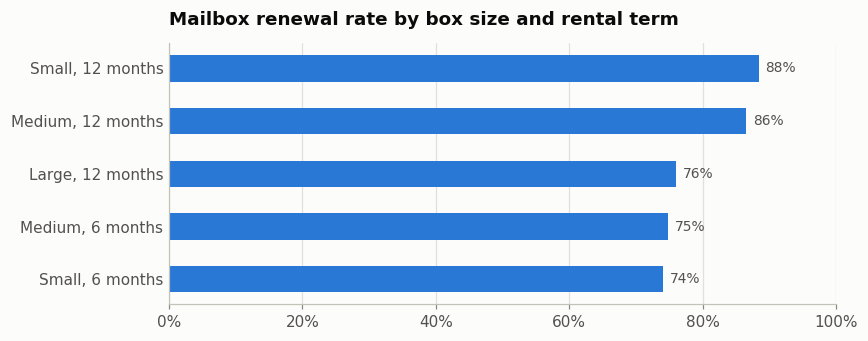

In [17]:
mailbox = sql("""
WITH rentals AS (
    SELECT customer_id, COUNT(*) AS rental_payments
    FROM sales
    WHERE status = 'Completed' AND service_id LIKE 'MBX-%' AND service_id <> 'MBX-KEY'
    GROUP BY customer_id
)
SELECT c.mailbox_size,
       c.mailbox_term_months AS term_months,
       COUNT(*) AS boxes,
       -- a box first rented during the period paid once to start; every other payment is a renewal
       SUM(MAX(COALESCE(r.rental_payments, 0) - (c.account_open_date >= '2024-09-01'), 0)) AS renewals,
       SUM(c.status = 'Closed') AS cancellations
FROM customers AS c
LEFT JOIN rentals AS r USING (customer_id)
WHERE c.customer_type = 'Mailbox holder'
GROUP BY c.mailbox_size, c.mailbox_term_months
""")
mailbox["renewal_rate"] = mailbox["renewals"] / (mailbox["renewals"] + mailbox["cancellations"])
display(show(mailbox, count=["boxes", "renewals", "cancellations"], pct=["renewal_rate"]))

chart = mailbox.sort_values("renewal_rate")
labels = chart["mailbox_size"] + ", " + chart["term_months"].astype(str) + " months"
y = np.arange(len(chart))
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(y, chart["renewal_rate"], height=0.5, color=BLUE)
for i, rate in enumerate(chart["renewal_rate"]):
    ax.text(rate + 0.01, i, f"{rate:.0%}", va="center", fontsize=9, color=INK_2)
ax.set_yticks(y, labels)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PERCENT)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_title("Mailbox renewal rate by box size and rental term")
plt.tight_layout()
plt.show()

**Your takeaway:** _Which boxes renew least? What could the store change to keep more of them?_

## 9. When is the store busiest, and is it staffed for it?

The left chart shows the average number of transactions in each hour. The right chart divides that by the number of staff scheduled at the half-hour mark, so darker cells are the hours when each person handles the most customers. Blank cells are hours when the store is closed.

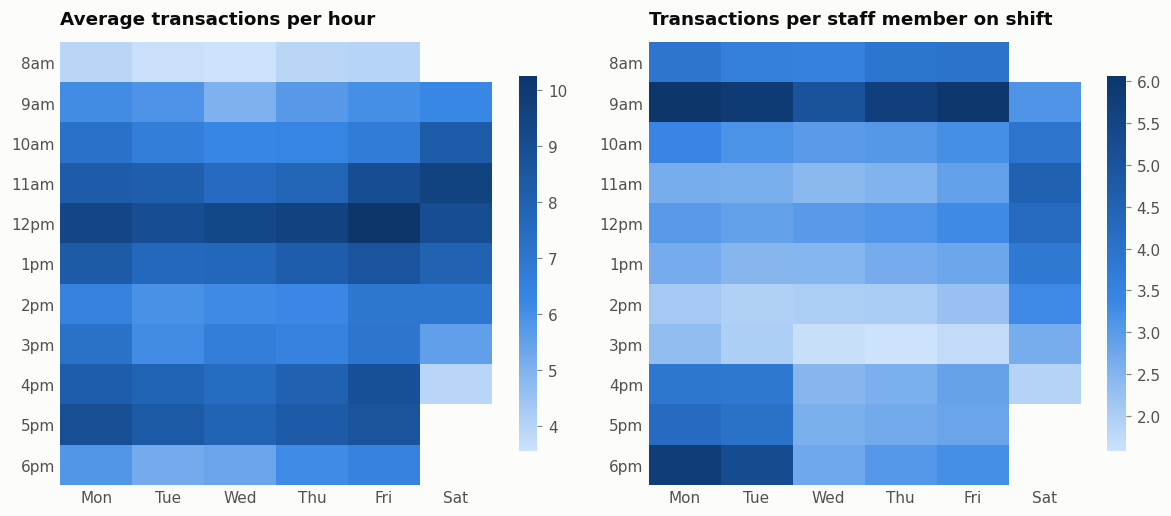

,Mon,Tue,Wed,Thu,Fri,Sat
hour,,,,,,
8,3.9,3.6,3.5,3.9,4.0,NaN
9,6.1,5.9,5.0,5.7,6.0,3.1
10,3.4,3.1,3.0,3.0,3.2,3.9
11,2.6,2.6,2.4,2.5,2.9,4.5
12,3.0,2.9,3.0,3.1,3.3,4.3
13,2.7,2.5,2.5,2.7,2.8,3.8
14,2.1,1.9,2.0,2.0,2.2,3.3
15,2.3,2.0,1.6,1.6,1.7,2.6
16,3.9,3.8,2.5,2.6,2.8,1.9


In [18]:
hourly = sql("""
SELECT date(transaction_datetime) AS day,
       CAST(strftime('%H', transaction_datetime) AS INTEGER) AS hour,
       COUNT(DISTINCT transaction_id) AS transactions
FROM sales
WHERE status = 'Completed'
GROUP BY day, hour
""")
shifts = sql("SELECT shift_date AS day, start_time, end_time FROM shifts")

WEEKDAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
HOURS = range(8, 19)
open_days = pd.to_datetime(shifts["day"].drop_duplicates())
days_per_weekday = open_days.dt.dayofweek.value_counts()

# average transactions in each hour, by weekday
hourly["weekday"] = pd.to_datetime(hourly["day"]).dt.dayofweek
avg_transactions = (hourly.groupby(["hour", "weekday"])["transactions"].sum()
                    .div(days_per_weekday, level="weekday").unstack())

# average staff on shift at half past each hour, by weekday
def to_hours(text):
    return int(text[:2]) + int(text[3:]) / 60

on_shift = [(day, hour)
            for day, start, end in zip(shifts["day"], shifts["start_time"].map(to_hours), shifts["end_time"].map(to_hours))
            for hour in HOURS if start <= hour + 0.5 < end]
staff = pd.DataFrame(on_shift, columns=["day", "hour"])
staff["weekday"] = pd.to_datetime(staff["day"]).dt.dayofweek
avg_staff = staff.groupby(["hour", "weekday"]).size().div(days_per_weekday, level="weekday").unstack()

avg_transactions = avg_transactions.reindex(index=HOURS, columns=range(6))
per_staff = avg_transactions / avg_staff.reindex(index=HOURS, columns=range(6))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, data, title in ((axes[0], avg_transactions, "Average transactions per hour"),
                        (axes[1], per_staff, "Transactions per staff member on shift")):
    image = ax.imshow(np.ma.masked_invalid(data.to_numpy(dtype=float)), cmap=BLUES, aspect="auto")
    ax.set_xticks(range(6), WEEKDAYS)
    ax.set_yticks(range(len(HOURS)), [f"{h % 12 or 12}{'am' if h < 12 else 'pm'}" for h in HOURS])
    ax.grid(False)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, shrink=0.85).outline.set_visible(False)
plt.tight_layout()
plt.show()

per_staff.set_axis(WEEKDAYS, axis=1).rename_axis("hour").round(1)

**Your takeaway:** _Which hours are the most stretched? Is there a shift change that would help without adding hours?_

## 10. Which services earn the most for the staff time they take?

Each service has a rough estimate of staff minutes per transaction line and per unit. For mailbox rentals it includes sorting the box's mail over the rental term. Gross profit divided by those minutes shows which services pay best for the time they take.

,category,gross_profit,labor_minutes,profit_per_labor_minute,staff_hours_per_year
6,Retail,"$5,130",512,10.03,4
4,Packing supplies,"$95,222","9,568",9.95,80
5,Printing,"$236,278","57,837",4.09,482
2,Other services,"$40,198","10,838",3.71,90
1,Notary,"$66,045","27,880",2.37,232
0,Mailbox,"$104,456","52,360",1.99,436
8,Shipping,"$195,010","102,378",1.90,853
3,Packing services,"$20,737","16,288",1.27,136
7,Returns,$0,"23,424",0.00,195


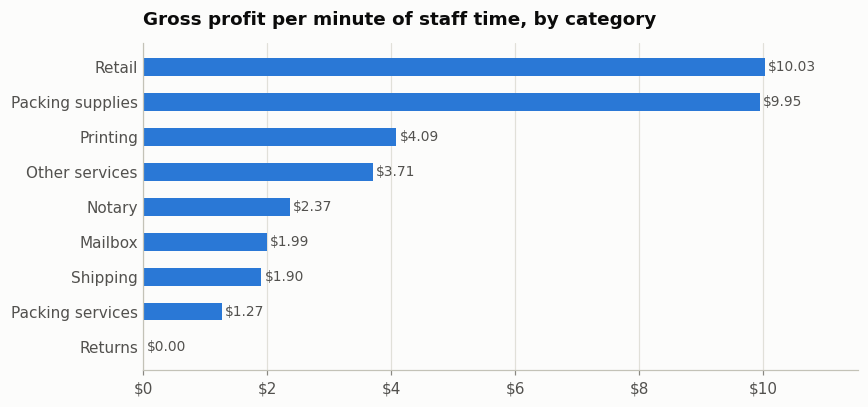

In [19]:
labor = sql("""
SELECT category,
       SUM(gross_profit) AS gross_profit,
       SUM(labor_min_per_line + labor_min_per_unit * quantity) AS labor_minutes
FROM sales
WHERE status = 'Completed'
GROUP BY category
""")
labor["profit_per_labor_minute"] = labor["gross_profit"] / labor["labor_minutes"]
labor["staff_hours_per_year"] = labor["labor_minutes"] / 60 / 2  # the data covers two years
labor = labor.sort_values("profit_per_labor_minute", ascending=False)
display(show(labor, money=["gross_profit"], count=["labor_minutes", "staff_hours_per_year"],
             decimals=["profit_per_labor_minute"]))

chart = labor.iloc[::-1]
y = np.arange(len(chart))
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(y, chart["profit_per_labor_minute"], height=0.5, color=BLUE)
for i, value in enumerate(chart["profit_per_labor_minute"]):
    ax.text(value + 0.05, i, f"${value:,.2f}", va="center", fontsize=9, color=INK_2)
ax.set_yticks(y, chart["category"])
ax.set_xlim(0, chart["profit_per_labor_minute"].max() * 1.15)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_title("Gross profit per minute of staff time, by category")
plt.tight_layout()
plt.show()

**Your takeaway:** _Which services pay best for the staff time they take? How many staff hours a year go to return drop-offs? How much would you trust these time estimates?_

## Your recommendation to the owner

Write three recommendations based on what you found. For each one, include:

- **What to do**
- **The evidence** from the sections above
- **What you expect it to change**, in dollars if you can estimate it

1.

2.

3.

**What I'd look at next:** _one question this data can't answer yet, and what data would answer it._

---

**Before the interview:** be ready to explain how each number was calculated. The questions most likely to come up are about the `sales` view (why voided sales are left out and refunds kept) and about sections 5, 6 and 8, which build a table of visits before counting.